In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers= 8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers= 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers= 8)

/user/HS401/ob00564/Documents/COM3001/KDEF/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/KDEF
Train set length: 2350
Test set length: 294
Validation set length: 294


In [4]:
import torchvision.models as models
emotionTotal = 7
myModel = models.mobilenet_v2(weights = 'DEFAULT')
myModel.classifier = torch.nn.Linear(in_features=1280, out_features= 7)
print(myModel)
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

# Unfreeze classifer layer
for param in myModel.classifier.parameters():
    param.requires_grad = True

# Unfreeze 16th, 17th, 18th layers
for id in range(16,19):
    for param in myModel.features[id].parameters():
        param.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [5]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.00001, momentum=0.96, weight_decay= 0.1)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)
train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'KDEF/Transfer Learning/KDEF MobileNetV2.pth')

100%|██████████| 147/147 [00:02<00:00, 64.47it/s]


Epoch 1/100, Training Loss: 1.9539, Validation Loss: 1.9326
Epoch 1/100, Training Acc: 14.923469387755103, Validation Accuracy: 21.271929824561404


100%|██████████| 147/147 [00:02<00:00, 70.25it/s]


Epoch 2/100, Training Loss: 1.9226, Validation Loss: 1.9106
Epoch 2/100, Training Acc: 19.399902818270164, Validation Accuracy: 21.600877192982455


100%|██████████| 147/147 [00:02<00:00, 69.68it/s]


...

Epoch 68/100, Training Loss: 0.4208, Validation Loss: 0.5163
Epoch 68/100, Training Acc: 85.15549076773567, Validation Accuracy: 81.68859649122807


100%|██████████| 147/147 [00:02<00:00, 65.91it/s]


Epoch 69/100, Training Loss: 0.4104, Validation Loss: 0.4980
Epoch 69/100, Training Acc: 86.08479105928086, Validation Accuracy: 80.70175438596492


100%|██████████| 147/147 [00:02<00:00, 65.39it/s]


Model saved successfully!


In [6]:
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

Test Loss: 0.5319, Test Accuracy: 78.91%


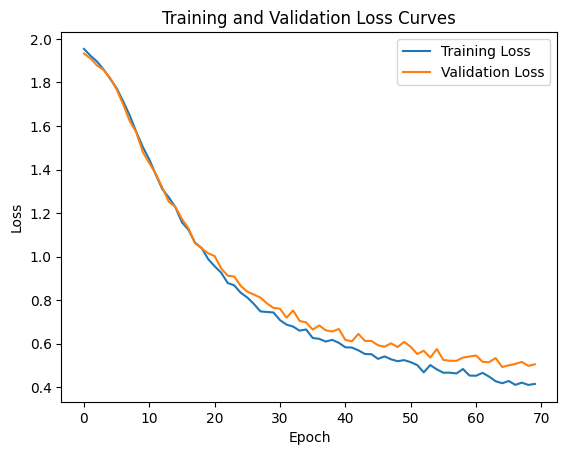

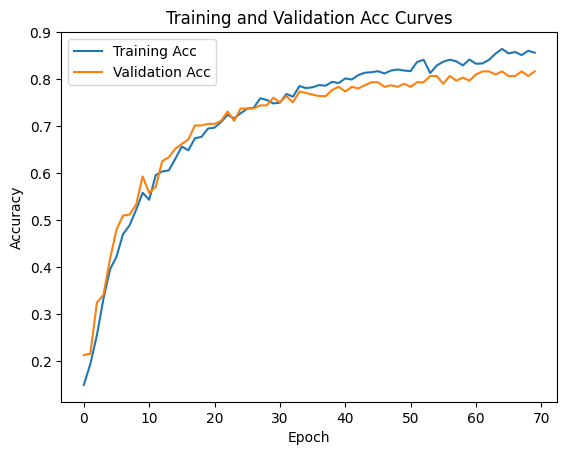

              precision    recall  f1-score   support

       Anger     0.7209    0.7381    0.7294        42
     Disgust     0.8421    0.7619    0.8000        42
        Fear     0.6667    0.6190    0.6420        42
   Happiness     0.9111    0.9762    0.9425        42
     Sadness     0.7750    0.7381    0.7561        42
    Surprise     0.7551    0.8810    0.8132        42
     Neurtal     0.8500    0.8095    0.8293        42

    accuracy                         0.7891       294
   macro avg     0.7887    0.7891    0.7875       294
weighted avg     0.7887    0.7891    0.7875       294



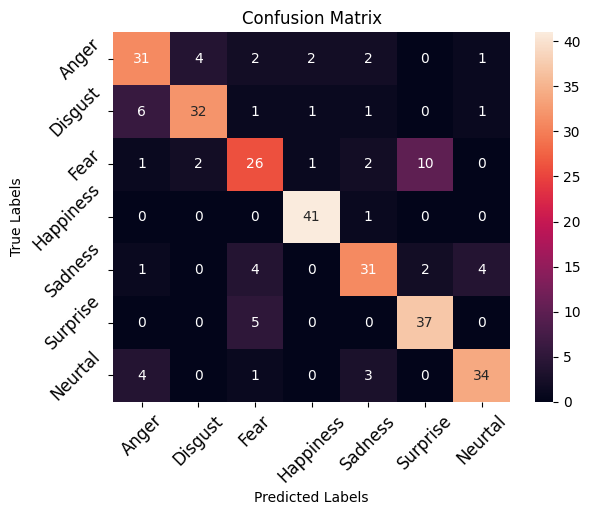

: 

In [7]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)